# Principal Component Analysis with Cancer Data

In [187]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [188]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [189]:
# Making a list of missing value types
missing_values = ["n/a", "na", "--", "?"]
cancer_df = pd.read_csv("cancer.csv", na_values = missing_values)

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [190]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    683 non-null float64
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: float64(1), int64(10)
memory usage: 60.1 KB


In [191]:
cancer_df.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [192]:
# Check if there are any null values 
cancer_df.isnull().values.any()

True

In [193]:
# We could see "?" values in column, this should be removed from data set
# Check for missing value in any other column

In [194]:
# Total missing values for each feature
cancer_df.isnull().sum()

ID                              0
ClumpThickness                  0
Cell Size                       0
Cell Shape                      0
Marginal Adhesion               0
Single Epithelial Cell Size     0
Bare Nuclei                    16
Normal Nucleoli                 0
Bland Chromatin                 0
Mitoses                         0
Class                           0
dtype: int64

In [195]:
# No missing values found. So let us try to remove ? from bare nuclei column
# Get count of rows having ?

In [196]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values of median

In [197]:
# Replace using median 
median_bare_nuclei = cancer_df['Bare Nuclei'].median()
cancer_df['Bare Nuclei'].fillna(median_bare_nuclei, inplace=True)

In [198]:
# Check if there are any null values 
cancer_df.isnull().values.any()

False

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [199]:
# Check for correlation of variable

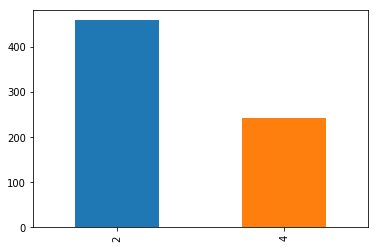

In [200]:
cancer_df['Class'].value_counts().plot(kind = 'bar')

In [201]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [202]:
#Let us check for pair plots

C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


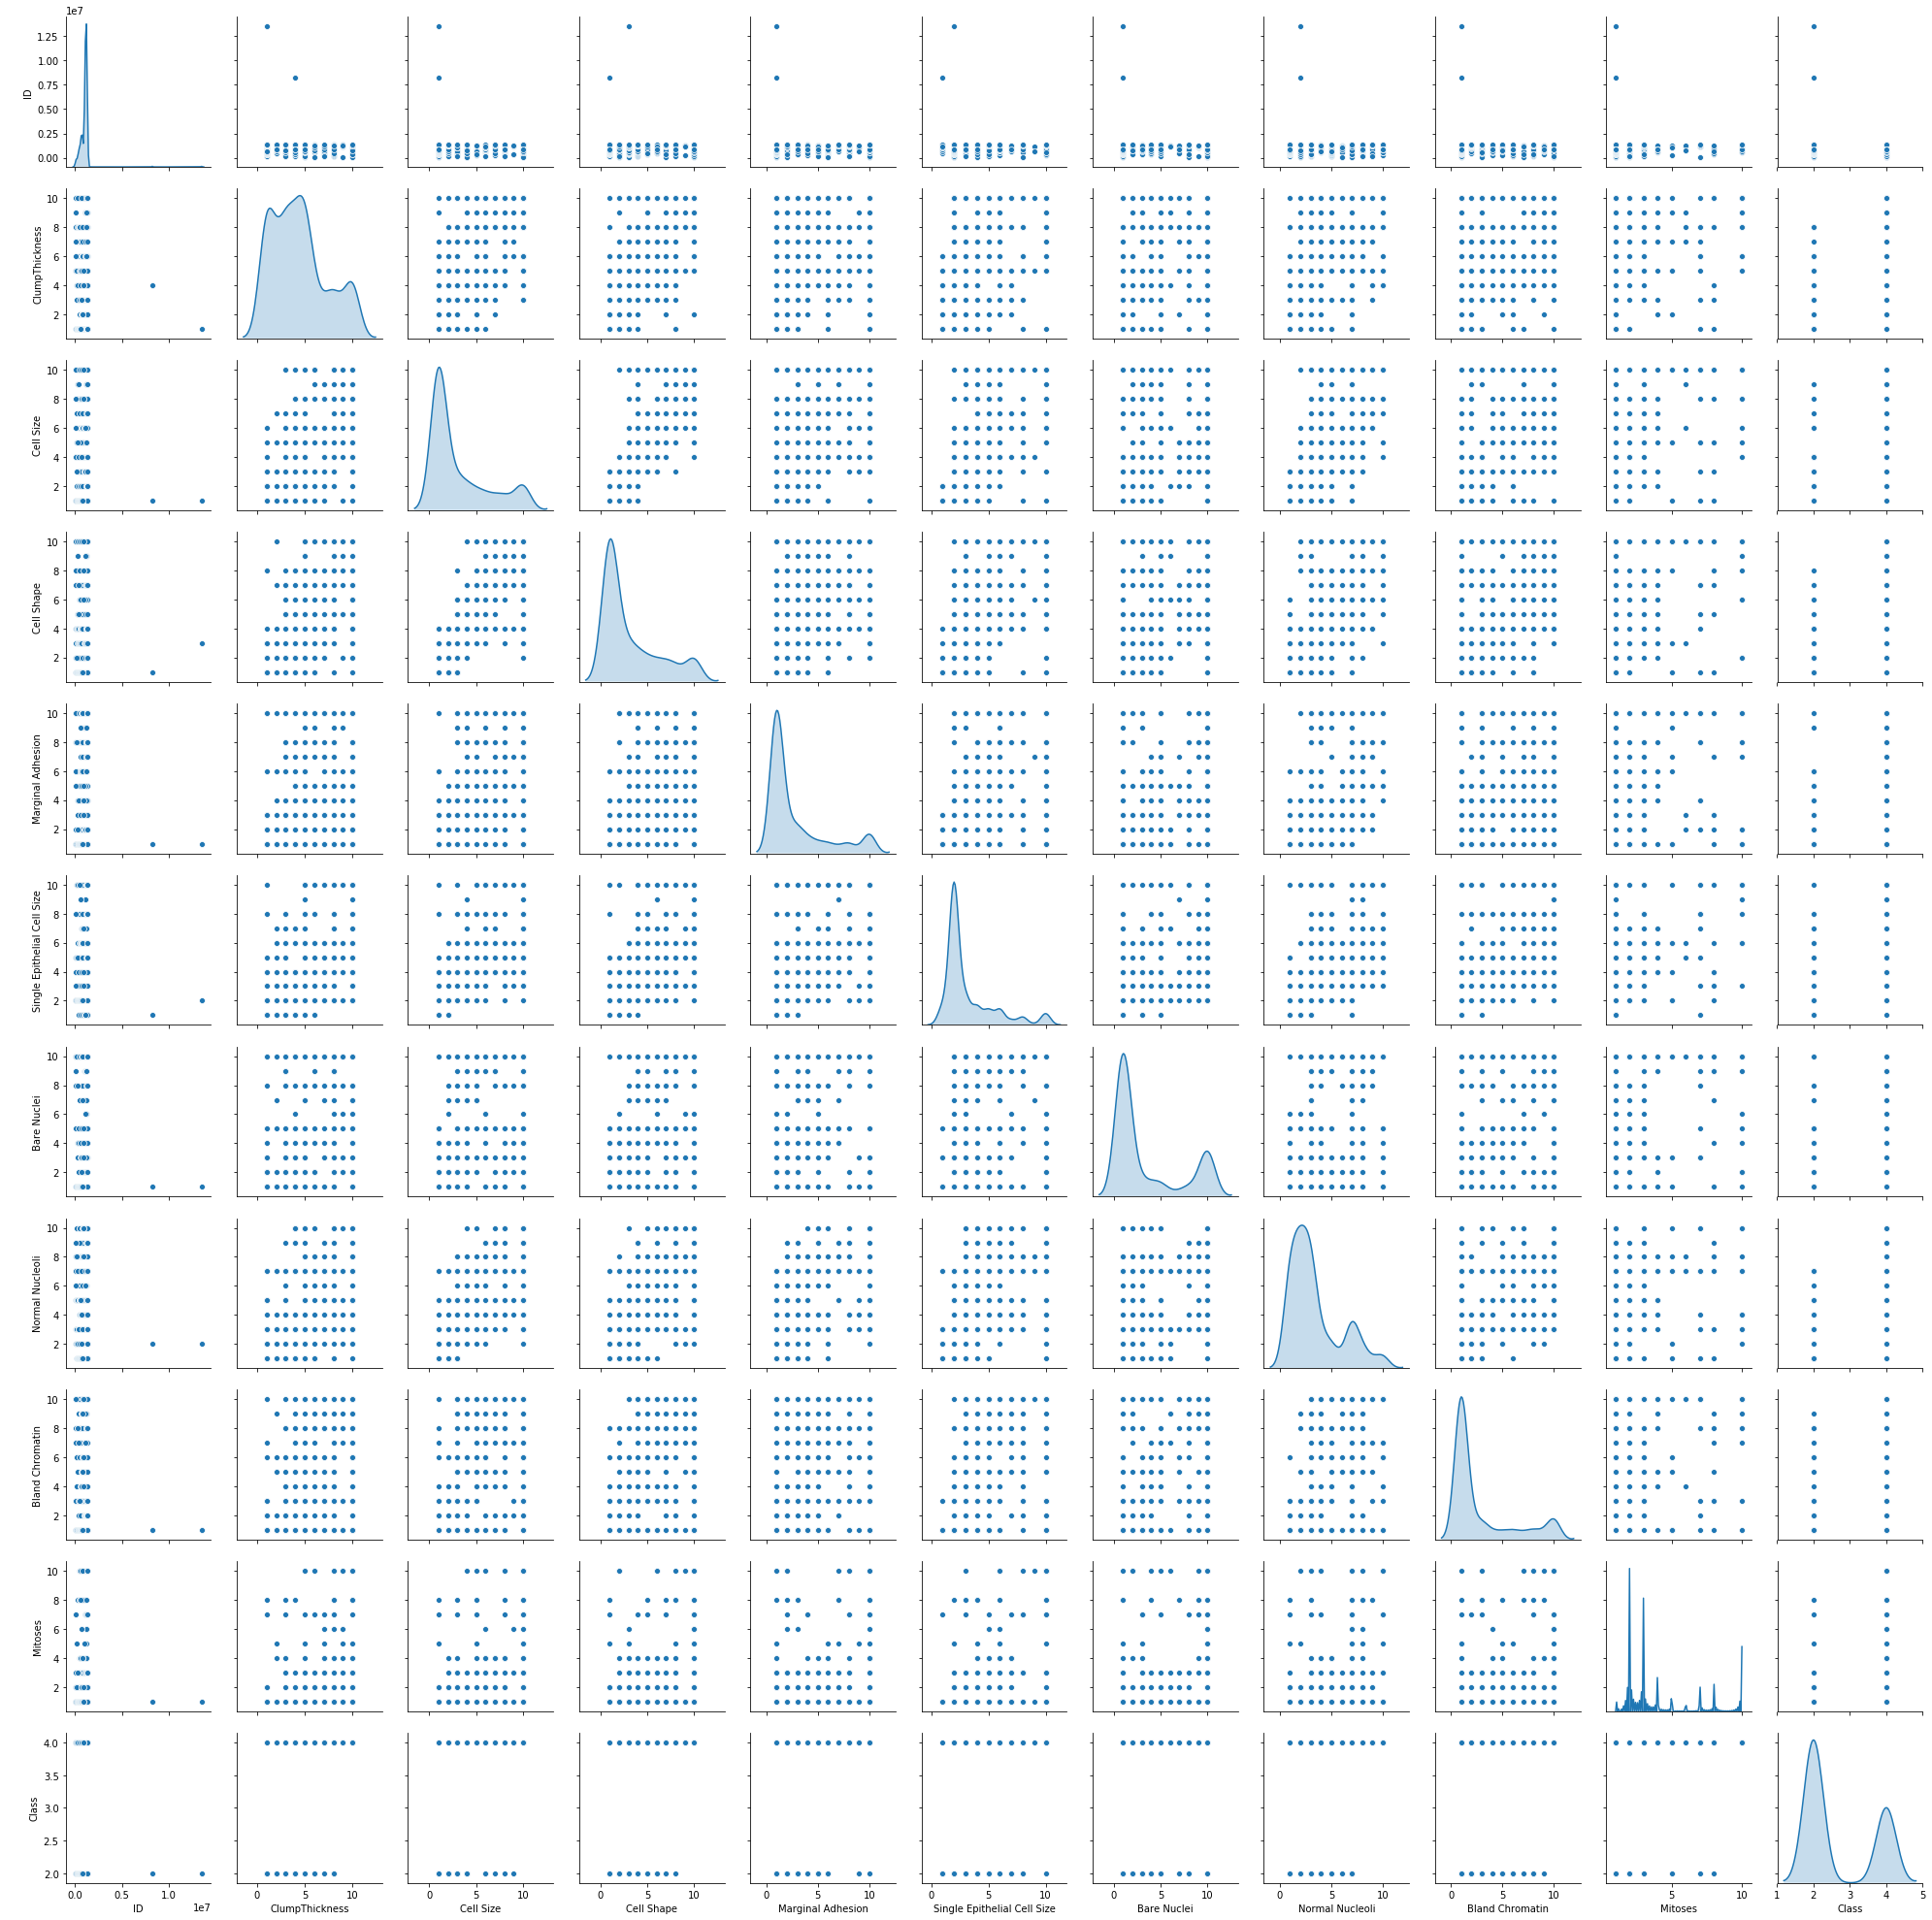

In [203]:
import seaborn as sns
# Pairplot using sns
sns.pairplot(cancer_df, diag_kind = "kde")

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [204]:
# We could see most of the outliers are now removed.

In [205]:
X =  cancer_df.drop("Class", axis=1)
y =  cancer_df['Class']

In [206]:
sc = StandardScaler()
X_std =  sc.fit_transform(X) 

C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q6 Create a covariance matrix for identifying Principal components

In [207]:
# PCA
# Step 1 - Create covariance matrix
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00143266 -0.05538768 -0.04166294 -0.04163563 -0.06497103 -0.0455935
  -0.09266525 -0.06013656 -0.05214655 -0.03495066]
 [-0.05538768  1.00143266  0.64583645  0.65552689  0.48705303  0.52256381
   0.5908535   0.5592282   0.53660222  0.35053534]
 [-0.04166294  0.64583645  1.00143266  0.90818117  0.70659267  0.75287621
   0.68765657  0.75680368  0.72390044  0.4593503 ]
 [-0.04163563  0.65552689  0.90818117  1.00143266  0.68405782  0.72069948
   0.70848734  0.73700282  0.72047704  0.43953974]
 [-0.06497103  0.48705303  0.70659267  0.68405782  1.00143266  0.60045809
   0.66792658  0.66767051  0.60421681  0.41823111]
 [-0.0455935   0.52256381  0.75287621  0.72069948  0.60045809  1.00143266
   0.5845377   0.61698451  0.62978166  0.47978787]
 [-0.09266525  0.5908535   0.68765657  0.70848734  0.66792658  0.5845377
   1.00143266  0.67518063  0.5756016   0.34288766]
 [-0.06013656  0.5592282   0.75680368  0.73700282  0.66767051  0.61698451
   0.67518063  1.00143266  0.66

# Q7 Identify eigen values and eigen vector

In [208]:
# Step 2- Get eigen values and eigen vector

In [209]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-3.31491869e-02 -9.94394189e-01 -5.63656313e-02  9.81157635e-04
   1.88835981e-03  7.05956214e-02  1.00431389e-02 -2.35426898e-02
  -2.79282046e-02  2.19286677e-02]
 [ 3.02676831e-01  6.18816821e-03 -1.45546172e-01  1.43314936e-03
   8.62162969e-01  8.99072568e-02  7.27302170e-02 -2.39129963e-01
   1.52829668e-02 -2.70273949e-01]
 [ 3.80859478e-01 -4.27324982e-02 -5.31233880e-02  7.35600520e-01
  -1.87637551e-02 -1.95586949e-01 -1.36836263e-01  4.45244701e-01
   2.15204648e-01 -8.54598835e-02]
 [ 3.77249002e-01 -3.93239148e-02 -8.86091500e-02 -6.65452585e-01
   3.48883123e-02 -1.68182825e-01 -1.04092971e-01  5.88396746e-01
   1.36078302e-01 -1.98004390e-02]
 [ 3.32707509e-01  1.35819684e-02 -4.29465752e-02 -4.66930534e-02
  -4.21825711e-01  4.72896959e-01  3.78994415e-02 -1.15906942e-01
  -5.12916425e-02 -6.82661344e-01]
 [ 3.36148205e-01 -3.80241018e-02  1.61252225e-01 -6.78527284e-02
  -1.09767726e-01 -3.72995911e-01 -6.85286310e-01 -4.50746734e-01
  -1.75041877e-

# Q8 Find variance and cumulative variance by each eigen vector

In [210]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.903944531468695, array([-0.03314919,  0.30267683,  0.38085948,  0.377249  ,  0.33270751,
        0.3361482 ,  0.33354707,  0.34579083,  0.33563797,  0.22967244])), (1.000798174184451, array([-0.99439419,  0.00618817, -0.0427325 , -0.03932391,  0.01358197,
       -0.0380241 ,  0.06221587,  0.00290989, -0.02274556, -0.04174353])), (0.775157154520008, array([-0.05636563, -0.14554617, -0.05312339, -0.08860915, -0.04294658,
        0.16125223, -0.24240399, -0.23008436,  0.02308233,  0.90823321])), (0.539599843885662, array([ 0.00188836,  0.86216297, -0.01876376,  0.03488831, -0.42182571,
       -0.10976773,  0.00306846, -0.19742046, -0.13131913,  0.0942726 ])), (0.4637108904050734, array([ 0.07059562,  0.08990726, -0.19558695, -0.16818282,  0.47289696,
       -0.37299591,  0.53709435,  0.00754001, -0.46170094,  0.23651806])), (0.38095640132792497, array([ 0.01004314,  0.07273022, -0.13683626, -0.10409297,  0.03789944,
       -0.68528631, -0.12687058,  0.25562095,  0.62849098,  0.1325033

In [211]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. 

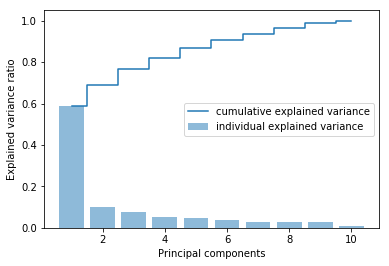

In [212]:
plt.bar(range(1,11), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,11),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

In [213]:
# P_reduce represents reduced mathematical space....
P_reduce = np.array(eigvectors_sorted[0:3])   # Reducing from 10 to 3 dimension space
X_std_4D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions
Proj_data_df = pd.DataFrame(X_std_4D)  # converting array to dataframe for pairplot

In [214]:
from sklearn import model_selection

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = model_selection.train_test_split(Proj_data_df, y, test_size=test_size, random_state=seed)

C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


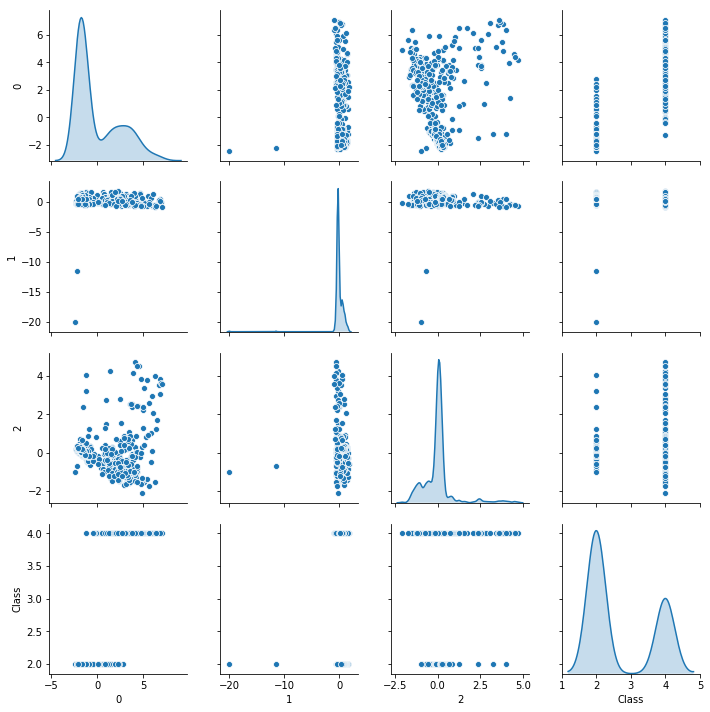

In [215]:
#Let us check it visually
Proj_data_class_df = Proj_data_df.join(y)

sns.pairplot(Proj_data_class_df, diag_kind='kde') 

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [216]:
from sklearn.decomposition import PCA

In [217]:
#PCA 
pca = PCA(n_components=3)
pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=3, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [218]:
#Get new dimensions
X_pca = pca.transform(X_std)
X_pca.shape

(699, 3)

# Q10 Find correlation between components and features

In [220]:
pca.components_

array([[-0.03314919,  0.30267683,  0.38085948,  0.377249  ,  0.33270751,
         0.3361482 ,  0.33354707,  0.34579083,  0.33563797,  0.22967244],
       [ 0.99439419, -0.00618817,  0.0427325 ,  0.03932391, -0.01358197,
         0.0380241 , -0.06221587, -0.00290989,  0.02274556,  0.04174353],
       [-0.05636563, -0.14554617, -0.05312339, -0.08860915, -0.04294658,
         0.16125223, -0.24240399, -0.23008436,  0.02308233,  0.90823321]])

In [221]:
pca.explained_variance_

array([5.90394453, 1.00079817, 0.77515715])

In [222]:
pca.explained_variance_ratio_

array([0.58954983, 0.09993664, 0.07740482])

#### PCA-1 captures 58.9% of the variance of the features 